# LAB 4. Задача 2. Графік часової складності

**Виконавець:** Сєров Едуард Олегович, група **К-26**  
**Викладач:** Ляшко А. В.  
**Варіант:** 90  (з lab2)

**Умова задачі:**  
За даними задачі 4 ЛР№2 побудувати графік функції (кусково-лінійне наближення).  
На тому самому зображенні іншим кольором побудувати графік знайденої в результаті обчислень функції.

In [1]:
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('lab2_var090.csv')
df.head()

,n,t
0,850,46056
1,164,4279
2,125,2649
3,45,533
4,417,16117


In [3]:
grouped = df.groupby('n').mean().reset_index()
df_t = pd.DataFrame({'const': 1.0, 'ln_n': np.log(grouped['n']), 'ln_t': np.log(grouped['t'])})
data_m = df_t.to_numpy()
X_m = data_m[:, :2]; Y_m = data_m[:, 2]
beta, _, _, _ = la.lstsq(X_m, Y_m)
a_est = beta[1]; c_est = np.exp(beta[0])
print(f'Оцінені параметри: c = {c_est:.6f}, a = {a_est:.6f}')

Оцінені параметри: c = 2.663346, a = 1.432833


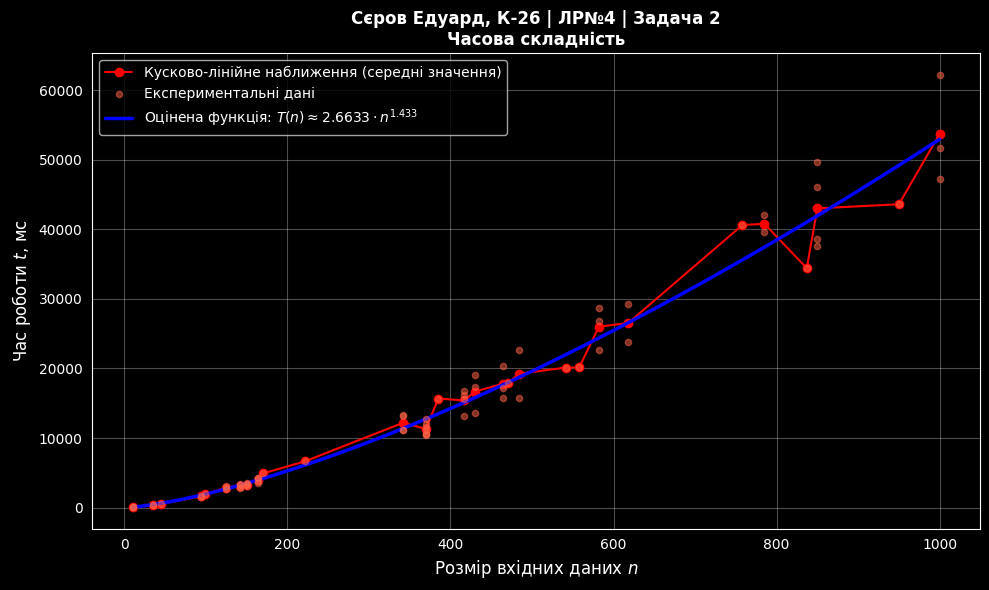

In [4]:
def T_estimated(n): return c_est * (n ** a_est)

n_raw = df['n'].values; t_raw = df['t'].values
scale = np.linspace(n_raw.min(), n_raw.max(), 300)
times = T_estimated(scale)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(grouped['n'], grouped['t'], color='red', marker='o', markersize=6,
        linewidth=1.5, linestyle='-', label='Кусково-лінійне наближення (середні значення)')
ax.scatter(n_raw, t_raw, color='tomato', s=20, alpha=0.5, zorder=3, label='Експериментальні дані')
ax.plot(scale, times, color='blue', linewidth=2.5,
        label=f'Оцінена функція: $T(n) \\approx {c_est:.4f} \\cdot n^{{{a_est:.3f}}}$')

ax.set_xlabel('Розмір вхідних даних $n$', fontsize=12)
ax.set_ylabel('Час роботи $t$, мс', fontsize=12)
ax.set_title('Сєров Едуард, К-26 | ЛР№4 | Задача 2\nЧасова складність', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task2_plot.png', dpi=<>:20: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:20: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:20: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:20: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
/tmp/ipykernel_327250/496406486.py:20: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  eq_label = r'$\dfrac{x^2}{a^2} + \dfrac{y^2}{b^2} - \dfrac{z^2}{c^2} = 1$' +            f'\n$a={a_p},\ b={b_p},\ c={c_p}$'
/tmp/ipykernel_327250/496406486.py:20: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  eq_label = r'$\dfrac{x^2}{a^2} + \dfrac{y^2}{b^2} - \dfrac{z^2}{c^2} = 1$' +            f'\n$a={a_p},\ b={b_p},\ c={c_p}$'150, bbox_inches='tight')
plt.show()